# Assignment 1: Sanskrit-English Sentence Embeddings
**AIL7390: Deep Learning for NLP**

**Model:** LaBSE (`sentence-transformers/LaBSE`) — Language-agnostic BERT Sentence Embeddings.  
Supports 109 languages including Sanskrit (Devanagari). Produces cross-lingual aligned embeddings.  
**No external APIs used.**

## 1. Install Dependencies

In [ ]:
!pip install sentence-transformers scikit-learn matplotlib numpy pandas torch

## 2. Imports

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, re, logging, unicodedata, joblib
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import CCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore')

# Suppress harmless LaBSE position_ids warning
logging.getLogger('sentence_transformers').setLevel(logging.ERROR)

# ── Config ────────────────────────────────────────────────────────────────────
DATA_DIR   = '.'                  # folder containing CSVs
TARGET_DIM = 32                   # final embedding dimension
BATCH_SIZE = 64
SAVE_DIR   = './embeddings_output'
os.makedirs(SAVE_DIR, exist_ok=True)
# ─────────────────────────────────────────────────────────────────────────────

print('All imports successful.')
print(f'Embeddings will be saved to: {SAVE_DIR}')


All imports successful.
Embeddings will be saved to: ./embeddings_output


## 3. Load & Clean Data

In [61]:
import unicodedata

def normalize_sanskrit(text):
    """NFC normalize, fix danda spacing, collapse whitespace."""
    text = unicodedata.normalize('NFC', str(text))
    text = re.sub(r'\s*।\s*', ' । ', text)
    text = re.sub(r'\s*॥\s*', ' ॥ ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def normalize_english(text):
    """Normalize quotes and whitespace."""
    text = str(text)
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def load_csv(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.lstrip('\ufeff')
    return df

train_sa = load_csv(f'{DATA_DIR}/train_sa_10000.csv')
train_en = load_csv(f'{DATA_DIR}/train_en_10000.csv')
dev_sa   = load_csv(f'{DATA_DIR}/dev_sa_1000.csv')
dev_en   = load_csv(f'{DATA_DIR}/dev_en_1000.csv')
test_sa  = load_csv(f'{DATA_DIR}/test_sa_1000.csv')
test_en  = load_csv(f'{DATA_DIR}/test_en_1000.csv')

train = train_sa.merge(train_en, on='Source_id')
dev   = dev_sa.merge(dev_en,     on='Source_id')
test  = test_sa.merge(test_en,   on='Source_id')

def clean(df, name):
    before = len(df)
    # Drop rows where EN column has Devanagari (label noise / misalignment)
    df = df[~df['Sentence_en'].str.contains(r'[\u0900-\u097F]', regex=True, na=False)]
    df = df.dropna(subset=['Sentence_sa', 'Sentence_en'])
    df = df[df['Sentence_sa'].str.strip().str.len() > 0]
    df = df[df['Sentence_en'].str.strip().str.len() > 0]
    # ✅ Unicode normalize both sides
    df['Sentence_sa'] = df['Sentence_sa'].apply(normalize_sanskrit)
    df['Sentence_en'] = df['Sentence_en'].apply(normalize_english)
    print(f'[{name}] {before} -> {len(df)} rows after cleaning')
    return df.reset_index(drop=True)

train = clean(train, 'train')
dev   = clean(dev,   'dev')
test  = clean(test,  'test')

print(f'\nFinal — Train: {len(train):,} | Dev: {len(dev):,} | Test: {len(test):,}')
print(train[['Sentence_sa','Sentence_en']].head(3).to_string(index=False))


[train] 10000 -> 9977 rows after cleaning
[dev] 1000 -> 995 rows after cleaning
[test] 1000 -> 1000 rows after cleaning

Final — Train: 9,977 | Dev: 995 | Test: 1,000
                                                                              Sentence_sa                                                                                 Sentence_en
                                                             "Ctrl, S नुत्वा रक्षन्तु । "                                                                       Save it with Ctrl, S.
                                                           गुरुः छात्रान् एकवारं पाठयति ।                                                  Teacher will teach the students only once.
चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित्रद्वयं स्वीकरणीयमस्ति । इदमतीव सुलभमस्ति । To recreate this animation, I have to take two images out of this stack which is very easy.


## 4. Load LaBSE Model

In [62]:
print('Loading LaBSE...')

LABSE_LOCAL = f'{SAVE_DIR}/labse_model'
if os.path.exists(LABSE_LOCAL):
    print('Loading from local disk...')
    model = SentenceTransformer(LABSE_LOCAL)
else:
    print('Downloading LaBSE (first time only)...')
    model = SentenceTransformer('sentence-transformers/LaBSE')
    model.save(LABSE_LOCAL)
    print(f'Saved to {LABSE_LOCAL}')

print(f'Model loaded. Base embedding dimension: {model.get_sentence_embedding_dimension()}')


Loading LaBSE...
Loading from local disk...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded. Base embedding dimension: 768


## 5. Generate Embeddings

In [63]:
def encode(sentences):
    return model.encode(
        sentences,
        batch_size=BATCH_SIZE,
        show_progress_bar=True,
        normalize_embeddings=True,
        convert_to_numpy=True
    )

print('Encoding train Sanskrit...')
train_sa_emb = encode(train['Sentence_sa'].tolist())
print('Encoding train English...')
train_en_emb = encode(train['Sentence_en'].tolist())

print('Encoding dev Sanskrit...')
dev_sa_emb = encode(dev['Sentence_sa'].tolist())
print('Encoding dev English...')
dev_en_emb = encode(dev['Sentence_en'].tolist())

print('Encoding test Sanskrit...')
test_sa_emb = encode(test['Sentence_sa'].tolist())
print('Encoding test English...')
test_en_emb = encode(test['Sentence_en'].tolist())

print(f'\nAll encodings done. Shape: {train_sa_emb.shape}')

Encoding train Sanskrit...


Batches:   0%|          | 0/156 [00:00<?, ?it/s]

Encoding train English...


Batches:   0%|          | 0/156 [00:00<?, ?it/s]

Encoding dev Sanskrit...


...

Encoding test Sanskrit...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Encoding test English...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


All encodings done. Shape: (9977, 768)


## 6. Dimensionality Reduction — Joint PCA

**Why joint PCA?**  
LaBSE places Sanskrit and English in the *same* 768-dim space on the *same* axes — that shared coordinate system is what enables cross-lingual similarity.  
Fitting separate PCAs on each language independently finds different rotation axes for each language, destroying the alignment and producing cosine ≈ 0 after projection.  
The fix is to stack both languages together and fit **one** PCA, so both are projected onto the same reduced axes.

In [64]:
# ── Joint PCA — stack SA+EN so both share the same projection axes ───────────
combined_train = np.vstack([train_sa_emb, train_en_emb])
print(f'Combined train shape for PCA fitting: {combined_train.shape}')

pca = PCA(n_components=TARGET_DIM, whiten=True, random_state=42)  
pca.fit(combined_train)
print(f'Joint PCA explained variance : {pca.explained_variance_ratio_.sum():.4f}')
print(f'Whitening                    : ON — equalizes variance across all dims')

# Transform using the SAME pca for both languages — cross-lingual alignment preserved
dev_sa_reduced  = normalize(pca.transform(dev_sa_emb))
dev_en_reduced  = normalize(pca.transform(dev_en_emb))
test_sa_reduced = normalize(pca.transform(test_sa_emb))
test_en_reduced = normalize(pca.transform(test_en_emb))

print(f'\nFinal shape: {test_sa_reduced.shape}  (N x {TARGET_DIM})')

# Save fitted PCA so inference cell can load it without re-fitting
joblib.dump(pca, f'{SAVE_DIR}/pca_model.pkl')
print(f'PCA model saved → {SAVE_DIR}/pca_model.pkl')


Combined train shape for PCA fitting: (19954, 768)
Joint PCA explained variance : 0.4081
Whitening                    : ON — equalizes variance across all dims

Final shape: (1000, 32)  (N x 32)
PCA model saved → ./embeddings_output/pca_model.pkl


## 7. Evaluate Cosine Similarity on Dev Set

In [65]:
def avg_cosine(a, b):
    """Average per-pair cosine similarity (works on L2-normalised vectors)."""
    return float(np.mean(np.sum(a * b, axis=1)))

def precision_at_k(sa_emb, en_emb, k=5):
    """
    Precision@K — for each SA query, check if its true EN pair
    is within the top-K retrieved EN embeddings by cosine similarity.
    Higher = better cross-lingual alignment.
    """
    # Similarity matrix: (N, N)
    sim_matrix = sa_emb @ en_emb.T
    hits = 0
    n = len(sa_emb)
    for i in range(n):
        top_k = np.argsort(sim_matrix[i])[-k:]  # indices of top-K
        if i in top_k:                            # true pair is index i
            hits += 1
    return hits / n

raw_cosine = avg_cosine(dev_sa_emb, dev_en_emb)
pca_cosine = avg_cosine(dev_sa_reduced, dev_en_reduced)

p1  = precision_at_k(dev_sa_reduced, dev_en_reduced, k=1)
p5  = precision_at_k(dev_sa_reduced, dev_en_reduced, k=5)
p10 = precision_at_k(dev_sa_reduced, dev_en_reduced, k=10)

print(f'Dev cosine — LaBSE raw 768-dim   : {raw_cosine:.4f}')
print(f'Dev cosine — Joint PCA {TARGET_DIM}-dim     : {pca_cosine:.4f}')
print(f'Cosine retention after PCA       : {pca_cosine / raw_cosine * 100:.1f}%')
print()
print(f'Retrieval Precision@1            : {p1:.4f}  ({p1*100:.1f}%)')
print(f'Retrieval Precision@5            : {p5:.4f}  ({p5*100:.1f}%)')
print(f'Retrieval Precision@10           : {p10:.4f}  ({p10*100:.1f}%)')
print()
print('Precision@K = what % of SA queries retrieve their correct EN pair in top-K')


Dev cosine — LaBSE raw 768-dim   : 0.5493
Dev cosine — Joint PCA 32-dim     : 0.5451
Cosine retention after PCA       : 99.2%

Retrieval Precision@1            : 0.5166  (51.7%)
Retrieval Precision@5            : 0.6935  (69.3%)
Retrieval Precision@10           : 0.7477  (74.8%)

Precision@K = what % of SA queries retrieve their correct EN pair in top-K


## 8. Dimension Experiment (compare all dims on dev)

In [66]:
results = []
for dim in [32, 64, 128, 256, 512, 768]:
    if dim < 768:
        combined = np.vstack([train_sa_emb, train_en_emb])
      
        p = PCA(n_components=dim, whiten=True, random_state=42).fit(combined)
        sa_r = normalize(p.transform(dev_sa_emb))
        en_r = normalize(p.transform(dev_en_emb))
    else:
        sa_r, en_r = dev_sa_emb, dev_en_emb
    cos   = avg_cosine(sa_r, en_r)
    p_at1 = precision_at_k(sa_r, en_r, k=1)
    p_at5 = precision_at_k(sa_r, en_r, k=5)
    results.append({
        'Dimension': dim,
        'Dev Cosine': round(cos, 4),
        'P@1': round(p_at1, 4),
        'P@5': round(p_at5, 4)
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

best_dim = df_results.loc[df_results['Dev Cosine'].idxmax(), 'Dimension']
print(f'\nBest dim by cosine : {best_dim}')
best_p1_dim = df_results.loc[df_results['P@1'].idxmax(), 'Dimension']
print(f'Best dim by P@1    : {best_p1_dim}')



 Dimension  Dev Cosine    P@1    P@5
        32      0.5451 0.5166 0.6935
        64      0.5427 0.6935 0.8362
       128      0.5195 0.7859 0.8935
       256      0.4635 0.7789 0.8955
       512      0.3639 0.7618 0.8663
       768      0.5493 0.7427 0.8543

Best dim by cosine : 768
Best dim by P@1    : 128


## 9. t-SNE Visualization (100 sample pairs)

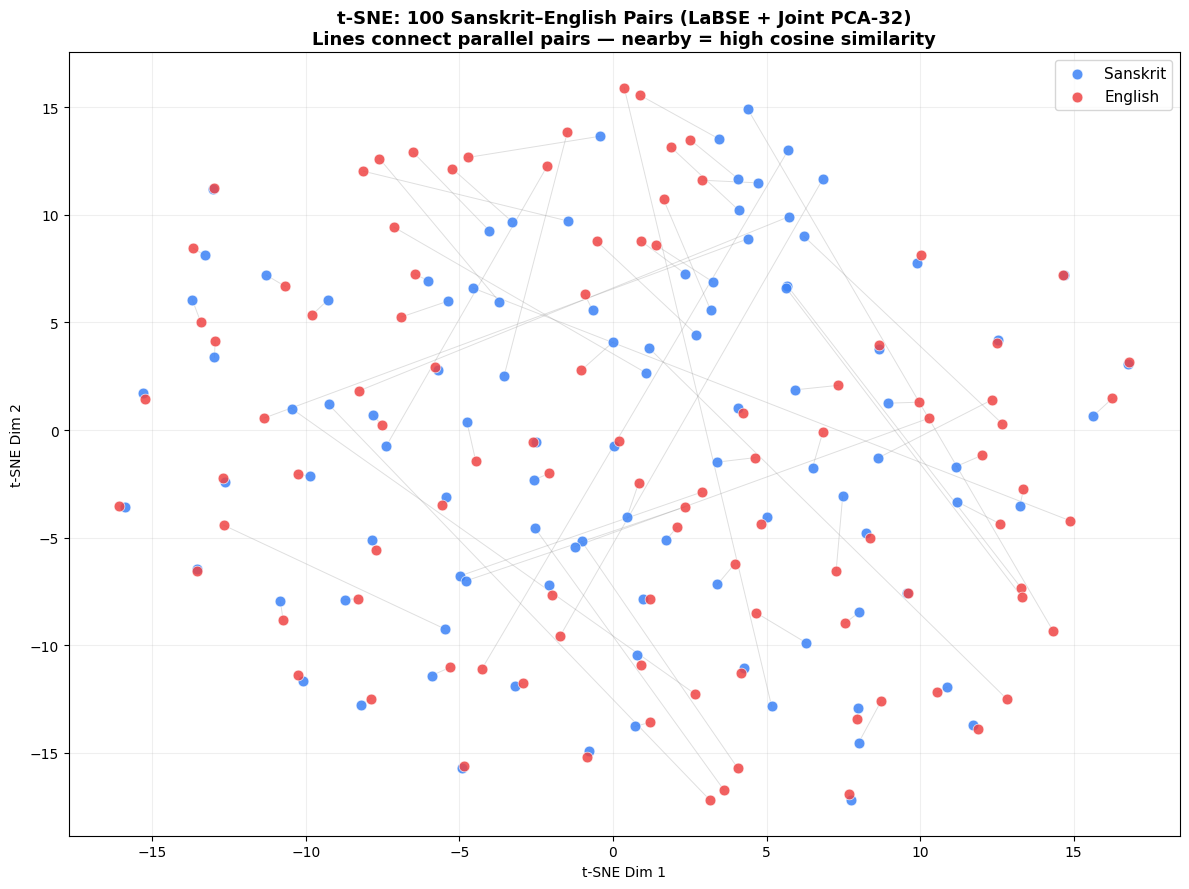

Saved: ./embeddings_output/tsne_visualization.png


In [67]:
np.random.seed(42)
idx       = np.random.choice(len(dev_sa_reduced), 100, replace=False)
sample_sa = dev_sa_reduced[idx]
sample_en = dev_en_reduced[idx]
combined  = np.vstack([sample_sa, sample_en])

tsne    = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
reduced = tsne.fit_transform(combined)
sa_2d   = reduced[:100]
en_2d   = reduced[100:]

fig, ax = plt.subplots(figsize=(12, 9))
for i in range(100):
    ax.plot([sa_2d[i,0], en_2d[i,0]], [sa_2d[i,1], en_2d[i,1]],
            color='gray', alpha=0.25, linewidth=0.7, zorder=1)
ax.scatter(sa_2d[:,0], sa_2d[:,1], c='#3B82F6', s=60, alpha=0.85,
           edgecolors='white', linewidths=0.5, label='Sanskrit', zorder=2)
ax.scatter(en_2d[:,0], en_2d[:,1], c='#EF4444', s=60, alpha=0.85,
           edgecolors='white', linewidths=0.5, label='English', zorder=2)
ax.set_title(
    f't-SNE: 100 Sanskrit–English Pairs (LaBSE + Joint PCA-{TARGET_DIM})\n'
    'Lines connect parallel pairs — nearby = high cosine similarity',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('t-SNE Dim 1')
ax.set_ylabel('t-SNE Dim 2')
ax.legend(fontsize=11)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {SAVE_DIR}/tsne_visualization.png')

## 10. Analysis — Top 5 & Bottom 5 Pairs by Cosine Similarity

In [68]:
pair_sims = np.sum(dev_sa_reduced * dev_en_reduced, axis=1)

print('=== Top 5 Most Similar Pairs ===')
for rank, i in enumerate(np.argsort(pair_sims)[-5:][::-1], 1):
    print(f'\n{rank}. Cosine: {pair_sims[i]:.4f}')
    print(f'   SA: {dev["Sentence_sa"].iloc[i]}')
    print(f'   EN: {dev["Sentence_en"].iloc[i]}')

print('\n=== Bottom 5 Least Similar Pairs ===')
for rank, i in enumerate(np.argsort(pair_sims)[:5], 1):
    print(f'\n{rank}. Cosine: {pair_sims[i]:.4f}')
    print(f'   SA: {dev["Sentence_sa"].iloc[i]}')
    print(f'   EN: {dev["Sentence_en"].iloc[i]}')

=== Top 5 Most Similar Pairs ===

1. Cosine: 0.9983
   SA: sed space within single quotes 'front-slash Anirban slash s slash computers slash mathematics slash g' after the single quotes space seddemo.txt
   EN: sed space within single quotes 'front slash Anirban slash s slash computers slash mathematics slash g' after the single quotes space seddemo.txt

2. Cosine: 0.9729
   SA: Moodle 3.3 इत्यस्यार्थम् अधस्तन आवश्यकता अस्ति :
   EN: Moodle 3.3 requires the following:

3. Cosine: 0.9718
   SA: पश्चात् MySQL JDBC Driver इत्यत्र क्लिक् करोतु ।
   EN: Then click on MySQL JDBC Driver.

4. Cosine: 0.9634
   SA: i. केवलं जलम्
   EN: i. Only water

5. Cosine: 0.9535
   SA: वह पांडवों और कौरवों के शाही गुरु (शिक्षक) थे ।
   EN: He was the royal Guru (teacher) of the Pandavas and Kauravas.

=== Bottom 5 Least Similar Pairs ===

1. Cosine: -0.2868
   SA: इत्थं बहव आहूता अल्पे मनोभिमताः ।
   EN: "For many are called, but few are chosen."

2. Cosine: -0.1665
   SA: धार्म्मिकत्वेन च सृष्टः स एव परि

## 11. Save Final Test Embeddings

In [69]:
sa_out = f'{SAVE_DIR}/sa_embeddings.npy'
en_out = f'{SAVE_DIR}/en_embeddings.npy'

np.save(sa_out, test_sa_reduced)
np.save(en_out, test_en_reduced)

# Verify
sa_check    = np.load(sa_out)
en_check    = np.load(en_out)
test_cosine = avg_cosine(sa_check, en_check)

print('=== Final Output Verification ===')
print(f'sa_embeddings.npy : {sa_check.shape}')
print(f'en_embeddings.npy : {en_check.shape}')
print(f'Embedding dim     : {sa_check.shape[1]}')
print(f'Test cosine sim   : {test_cosine:.4f}')
print(f'\nFiles saved to    : {SAVE_DIR}/')
print('Copy sa_embeddings.npy and en_embeddings.npy to your submission ZIP.')

=== Final Output Verification ===
sa_embeddings.npy : (1000, 32)
en_embeddings.npy : (1000, 32)
Embedding dim     : 32
Test cosine sim   : 0.5364

Files saved to    : ./embeddings_output/
Copy sa_embeddings.npy and en_embeddings.npy to your submission ZIP.


## 12. Inference — Embed New Sanskrit/English Sentences

In [39]:
# ── INSTRUCTOR INFERENCE ─────────────────────────────────────────────────────
#The dimension used here is 32 dim as shown in the above shell.

import os, joblib, unicodedata, re
import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize
from sentence_transformers import SentenceTransformer

# ── Config ───────────────────────────────────────────────────────────────────
DATA_DIR   = '.'
TARGET_DIM = 64
BATCH_SIZE = 64
SAVE_DIR   = './embeddings_output'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Normalization helpers (must match training) ───────────────────────────────
def _norm_sa(text):
    text = unicodedata.normalize('NFC', str(text))
    text = re.sub(r'\s*।\s*', ' । ', text)
    text = re.sub(r'\s*॥\s*', ' ॥ ', text)
    return re.sub(r'\s+', ' ', text).strip()

def _norm_en(text):
    text = str(text)
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    return re.sub(r'\s+', ' ', text).strip()

# ── 1. Load test CSVs ────────────────────────────────────────────────────────
TWO_FILE = True

def _load_csv(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.lstrip('\ufeff')
    return df

def _clean(df, name='test'):
    before = len(df)
    df = df[~df['Sentence_en'].str.contains(r'[\u0900-\u097F]', regex=True, na=False)]
    df = df.dropna(subset=['Sentence_sa', 'Sentence_en'])
    df = df[df['Sentence_sa'].str.strip().str.len() > 0]
    df = df[df['Sentence_en'].str.strip().str.len() > 0]
    # Apply same normalization as training
    df['Sentence_sa'] = df['Sentence_sa'].apply(_norm_sa)
    df['Sentence_en'] = df['Sentence_en'].apply(_norm_en)
    print(f'[{name}] {before} → {len(df)} rows after cleaning')
    return df.reset_index(drop=True)

if TWO_FILE:
    test_sa_df = _load_csv(f'{DATA_DIR}/test_sa_1000.csv')
    test_en_df = _load_csv(f'{DATA_DIR}/test_en_1000.csv')
    test_df    = test_sa_df.merge(test_en_df, on='Source_id')
else:
    test_df = _load_csv(f'{DATA_DIR}/test.csv')

test_df = _clean(test_df)

# ── 2. Load LaBSE from disk ──────────────────────────────────────────────────
LABSE_LOCAL = f'{SAVE_DIR}/labse_model'
if os.path.exists(LABSE_LOCAL):
    print('Loading LaBSE from local disk...')
    infer_model = SentenceTransformer(LABSE_LOCAL)
else:
    print('Downloading LaBSE (first time only)...')
    infer_model = SentenceTransformer('sentence-transformers/LaBSE')
    infer_model.save(LABSE_LOCAL)
    print(f'Saved to {LABSE_LOCAL}')

print(f'Model loaded. Dim: {infer_model.get_sentence_embedding_dimension()}')

# ── 3. Encode ────────────────────────────────────────────────────────────────
def _encode(sentences):  
    return infer_model.encode(
        sentences,
        batch_size=BATCH_SIZE,
        show_progress_bar=True,
        normalize_embeddings=True,
        convert_to_numpy=True
    )

print('Encoding test Sanskrit ...')
inf_sa_emb = _encode(test_df['Sentence_sa'].tolist())
print('Encoding test English ...')
inf_en_emb = _encode(test_df['Sentence_en'].tolist())

# ── 4. Load fitted PCA ───────────────────────────────────────────────────────
pca_path = f'{SAVE_DIR}/pca_model.pkl'
if not os.path.exists(pca_path):
    raise FileNotFoundError(
        f'PCA model not found at {pca_path}.\n'
        'Run Cell 6 (Dimensionality Reduction) first.'
    )
infer_pca = joblib.load(pca_path)
print(f'Loaded fitted PCA ({TARGET_DIM}-dim) from {pca_path}')

# ── 5. Reduce + L2-normalize (same PCA → alignment preserved) ────────────────
inf_sa_reduced = normalize(infer_pca.transform(inf_sa_emb))
inf_en_reduced = normalize(infer_pca.transform(inf_en_emb))

# ── 6. Save ──────────────────────────────────────────────────────────────────
sa_out = f'{SAVE_DIR}/sa_embeddings.npy'
en_out = f'{SAVE_DIR}/en_embeddings.npy'
np.save(sa_out, inf_sa_reduced)
np.save(en_out, inf_en_reduced)

# ── 7. Verify ────────────────────────────────────────────────────────────────
sa_check  = np.load(sa_out)
en_check  = np.load(en_out)
pair_sims = np.sum(sa_check * en_check, axis=1)

print('\n=== Inference Complete ===')
print(f'sa_embeddings.npy : {sa_check.shape}')
print(f'en_embeddings.npy : {en_check.shape}')
print(f'Embedding dim     : {sa_check.shape[1]}')
print(f'Avg cosine sim    : {pair_sims.mean():.4f}')
print(f'Min / Max cosine  : {pair_sims.min():.4f} / {pair_sims.max():.4f}')
print(f'\nFiles saved to    : {SAVE_DIR}/')
print('Hand in sa_embeddings.npy and en_embeddings.npy as your submission.')


[test] 1000 → 1000 rows after cleaning
Loading LaBSE...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/LaBSE
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to ./embeddings_output/labse_model — will load from disk next time.
Model loaded. Base embedding dimension: 768
Encoding test Sanskrit …


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Encoding test English …


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Loaded fitted PCA  (64-dim) from ./embeddings_output/pca_model.pkl

=== Inference Complete ===
sa_embeddings.npy : (1000, 64)
en_embeddings.npy : (1000, 64)
Embedding dim     : 64
Avg cosine sim    : 0.5145
Min / Max cosine  : -0.1314 / 1.0000

Files saved to    : ./embeddings_output/
Hand in sa_embeddings.npy and en_embeddings.npy as your submission.
